In [1]:
!pip install wilds matplotlib torch torchvision



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
from wilds import get_dataset
from wilds.common.data_loaders import get_train_loader
import torchvision.transforms as transforms
import pandas.core.tools.datetimes as _pd_dt_module
import matplotlib.pyplot as plt
import pandas as pd


my_root_path = "/mnt/windows/Users/kevin/Downloads/"

_true_orig_to_datetime = _pd_dt_module.to_datetime

def _patched_to_datetime(*args, **kwargs):
    # Always force ISO8601 — overrides missing OR incorrect format
    kwargs['format'] = 'ISO8601'
    return _true_orig_to_datetime(*args, **kwargs)

pd.to_datetime = _patched_to_datetime

dataset = get_dataset(dataset="fmow", root_dir=my_root_path, download=False)

# Restore
pd.to_datetime = _true_orig_to_datetime

# 1. Grab the pre-built, rich pandas DataFrame directly from the dataset
df = dataset.metadata.copy()

# 2. Extract the year safely by explicitly defining the ISO8601 format
#converte la stringa timestamp in oggetti
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601')
#dt serve per accedere ai campi
df['year_extracted'] = df['timestamp'].dt.year


# 1. Find the exact column index for 'region' in the metadata_array
region_idx = dataset.metadata_fields.index('region')

# 2. Retrieve the mapping list from the dataset (e.g., ['Asia', 'Europe', ...])
region_names_list = dataset.metadata_map['region']

df['region_names'] = df['region'].map(lambda x: region_names_list[int(x)])

# \. Ensure we have human-readable category names
# If the 'category' column contains numbers, we reverse the category_to_idx dict to map them.
# (If it already contains strings, this just safely skips the mapping).
if pd.api.types.is_numeric_dtype(df['category']):
    idx_to_category = {v: k for k, v in dataset.category_to_idx.items()}
    df['category_name'] = df['category'].map(idx_to_category)
else:
    df['category_name'] = df['category']

In [3]:
df['category']

0         tunnel_opening
1         tunnel_opening
2         tunnel_opening
3         tunnel_opening
4         tunnel_opening
               ...      
523841       burial_site
523842       burial_site
523843       burial_site
523844       burial_site
523845       burial_site
Name: category, Length: 523846, dtype: str

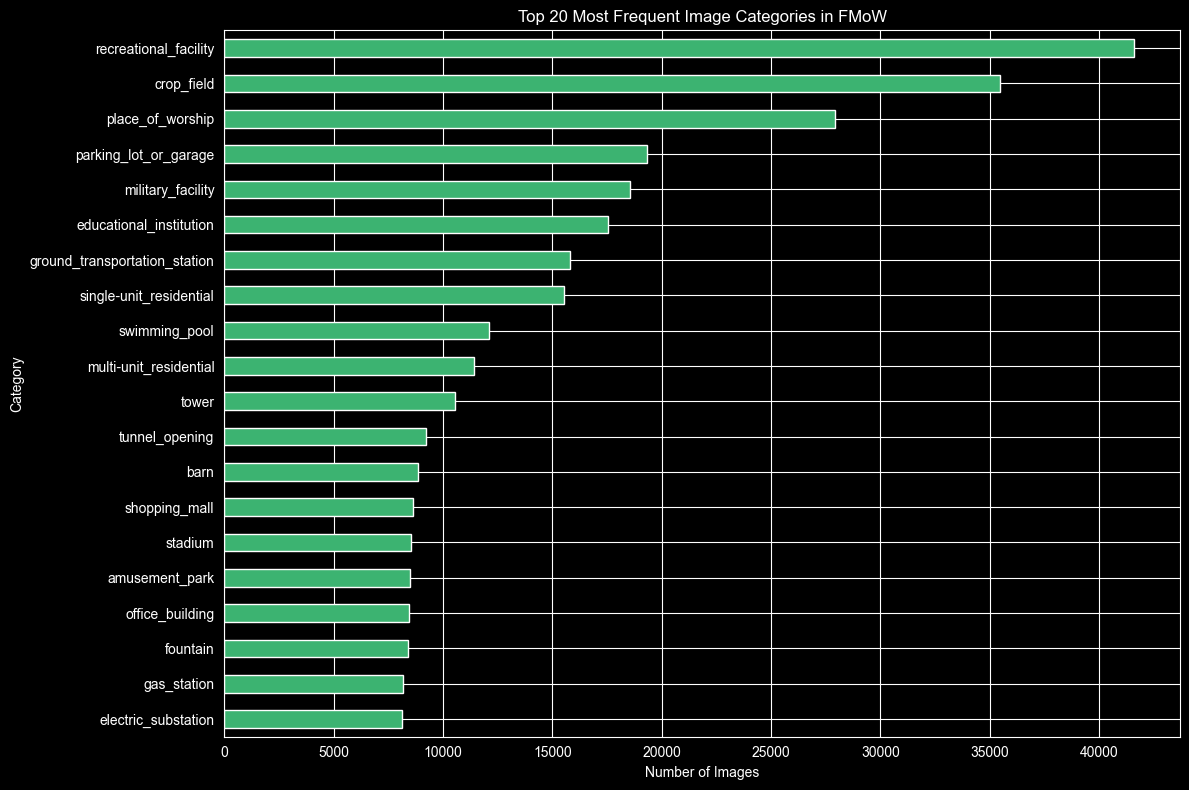

In [4]:

# ---------------------------------------------------------
# CHART 1: Top 20 Building / Land-Use Categories
# ---------------------------------------------------------
plt.figure(figsize=(12, 8))
top_categories = df['category_name'].value_counts().head(20)
top_categories.plot(kind='barh', color='mediumseagreen')
plt.title('Top 20 Most Frequent Image Categories in FMoW')
plt.xlabel('Number of Images')
plt.ylabel('Category')
plt.gca().invert_yaxis() # Put the largest bar at the top
plt.tight_layout()
plt.show()







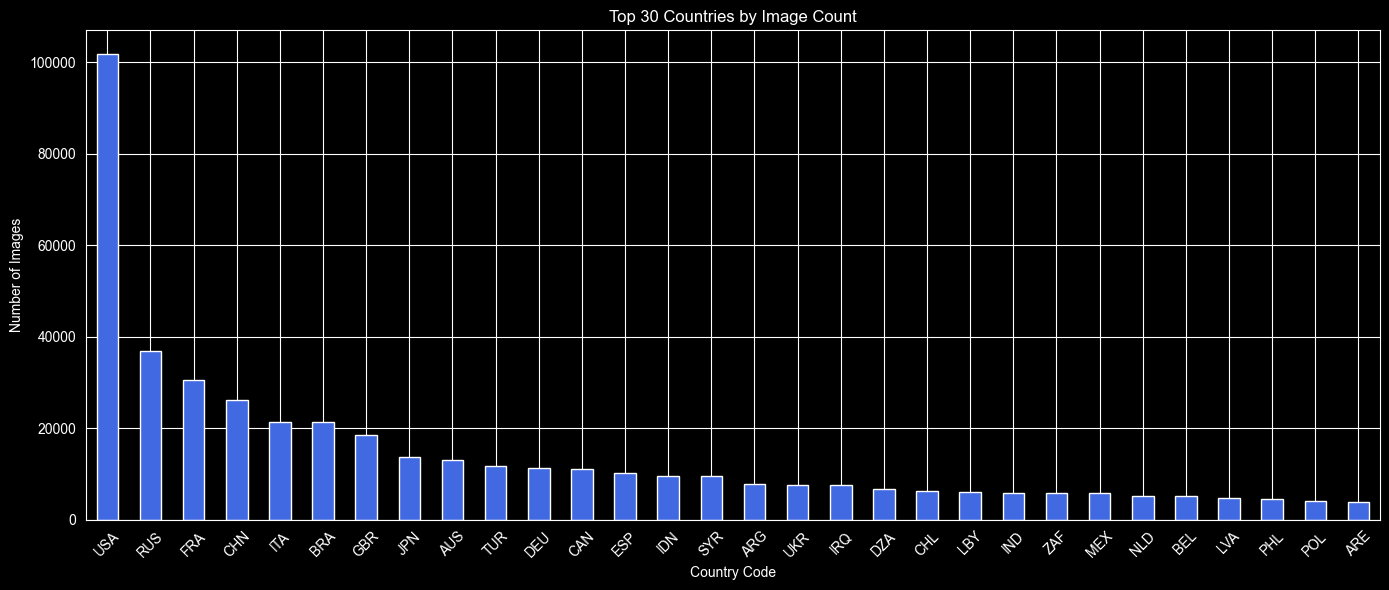

In [5]:
# ---------------------------------------------------------
# CHART 2: Image Distribution by Country Code
# ---------------------------------------------------------
plt.figure(figsize=(14, 6))
# Grabbing the top 30 country code
top_countries = df['country_code'].value_counts().head(30)
top_countries.plot(kind='bar', color='royalblue')
plt.title('Top 30 Countries by Image Count')
plt.xlabel('Country Code')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

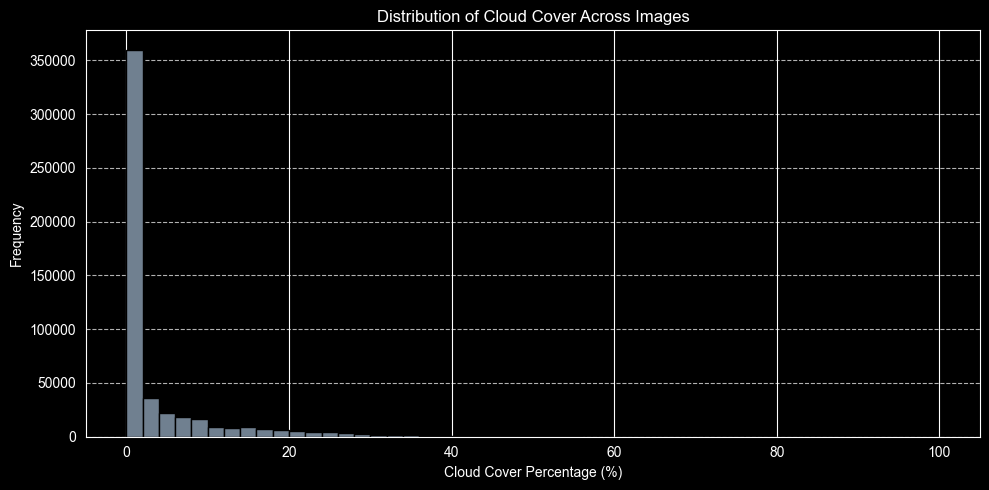

In [6]:
# ---------------------------------------------------------
# CHART 3: Cloud Cover Distribution
# ---------------------------------------------------------
# Satellite imagery often suffers from cloud obstruction.

plt.figure(figsize=(10, 5))
# Cloud cover is usually a percentage from 0 to 100
plt.hist(df['cloud_cover'], bins=50, color='slategray', edgecolor='black')
plt.title('Distribution of Cloud Cover Across Images')
plt.xlabel('Cloud Cover Percentage (%)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

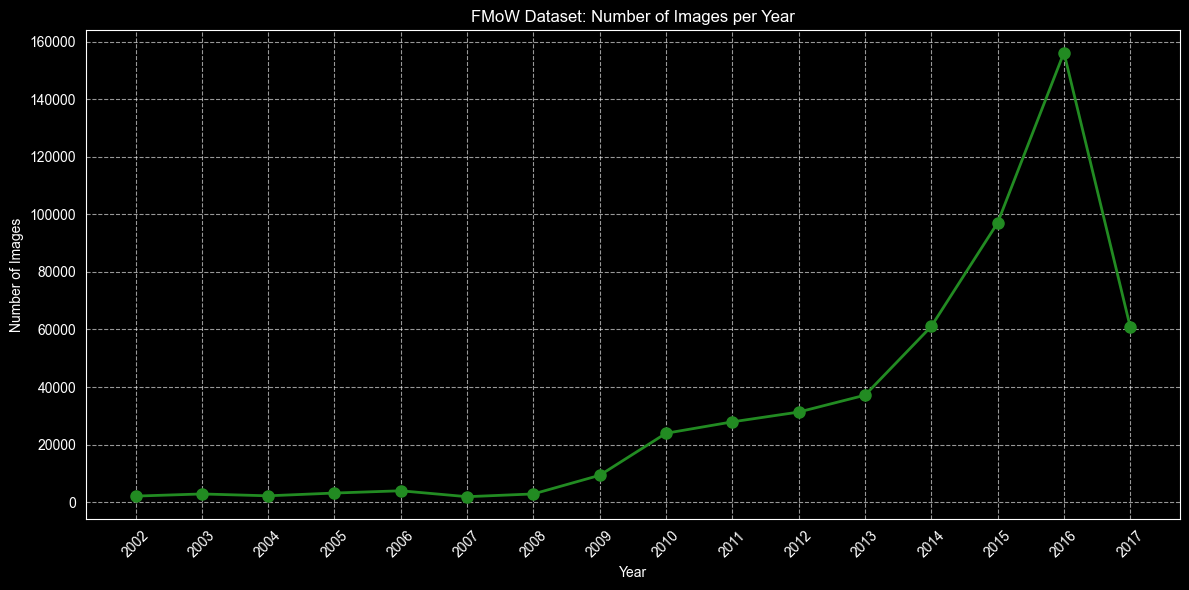

In [8]:
# ---------------------------------------------------------
# NOTEBOOK CELL 1: Year Distribution (Fixed)
# ---------------------------------------------------------


# 3. Plot the distribution over time
plt.figure(figsize=(12, 6))
year_counts = df['year_extracted'].value_counts().sort_index()

year_counts.plot(kind='line', marker='o', color='forestgreen', linewidth=2, markersize=8)
plt.title('FMoW Dataset: Number of Images per Year')
plt.xlabel('Year')
plt.ylabel('Number of Images')
plt.grid(True, linestyle='--', alpha=0.6)

# Force the x-axis to display as clean integers
plt.xticks(year_counts.index, [int(y) for y in year_counts.index], rotation=45)

plt.tight_layout()
plt.show()

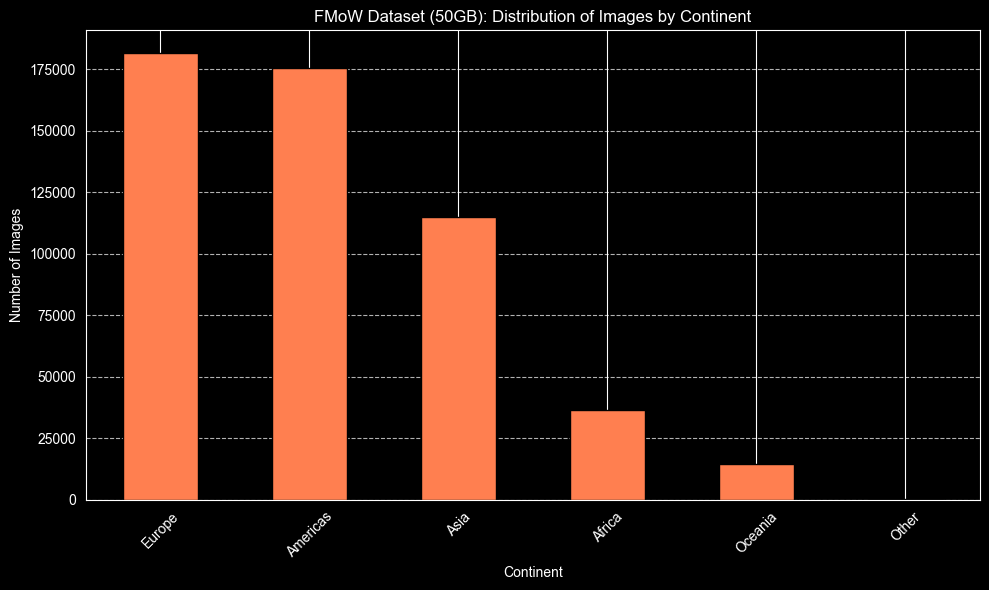

--- Images per Continent ---
region_names
Europe      181601
Americas    175597
Asia        115038
Africa       36722
Oceania      14616
Other          272


In [16]:
# ---------------------------------------------------------
# NOTEBOOK CELL: Continent / Region Distribution
# ---------------------------------------------------------


# 5. Calculate counts and plot
plt.figure(figsize=(10, 6))
continent_counts = df['region_names'].value_counts()

# Create a clean bar chart
continent_counts.plot(kind='bar', color='coral', edgecolor='black')

# Personalizing the title since we know we are analyzing the full 50GB dataset!
plt.title('FMoW Dataset (50GB): Distribution of Images by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Images')

# Rotate the labels so they are easy to read
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Print a quick text summary below the chart
print("--- Images per Continent ---")
print(continent_counts.to_string())

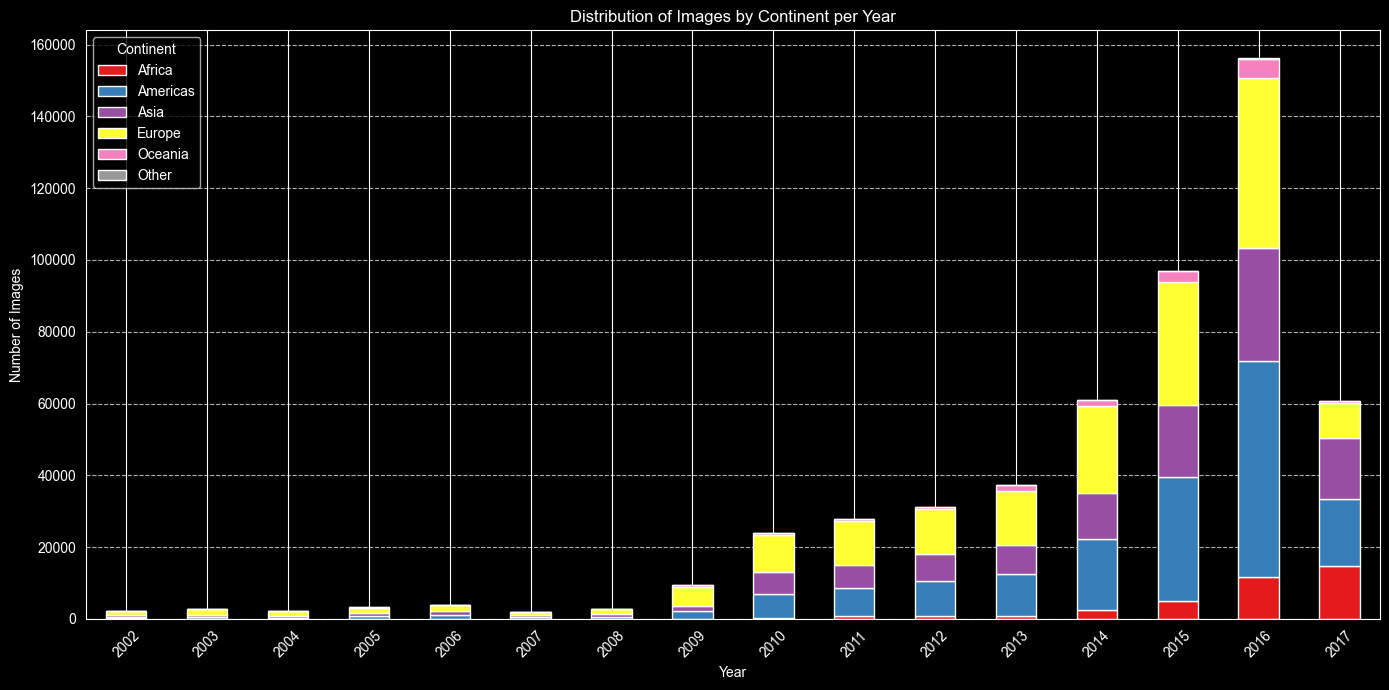

In [15]:
#ordinare per ogni anno, ogni continente (fissato un anno, voglio sapere la distribuzione delle immagini per continente)


# 1. Group by Year and Region, count them, and 'unstack' to pivot the regions into columns
# (Note: Using 'year_extracted' from the previous cell to ensure clean year numbers)
data_pivot = df.groupby(['year_extracted', 'region_names']).size().unstack(fill_value=0)


# 2. Plot as a stacked bar chart
data_pivot.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set1')

plt.title('Distribution of Images by Continent per Year')
plt.xlabel('Year')
plt.ylabel('Number of Images')
plt.legend(title='Continent')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

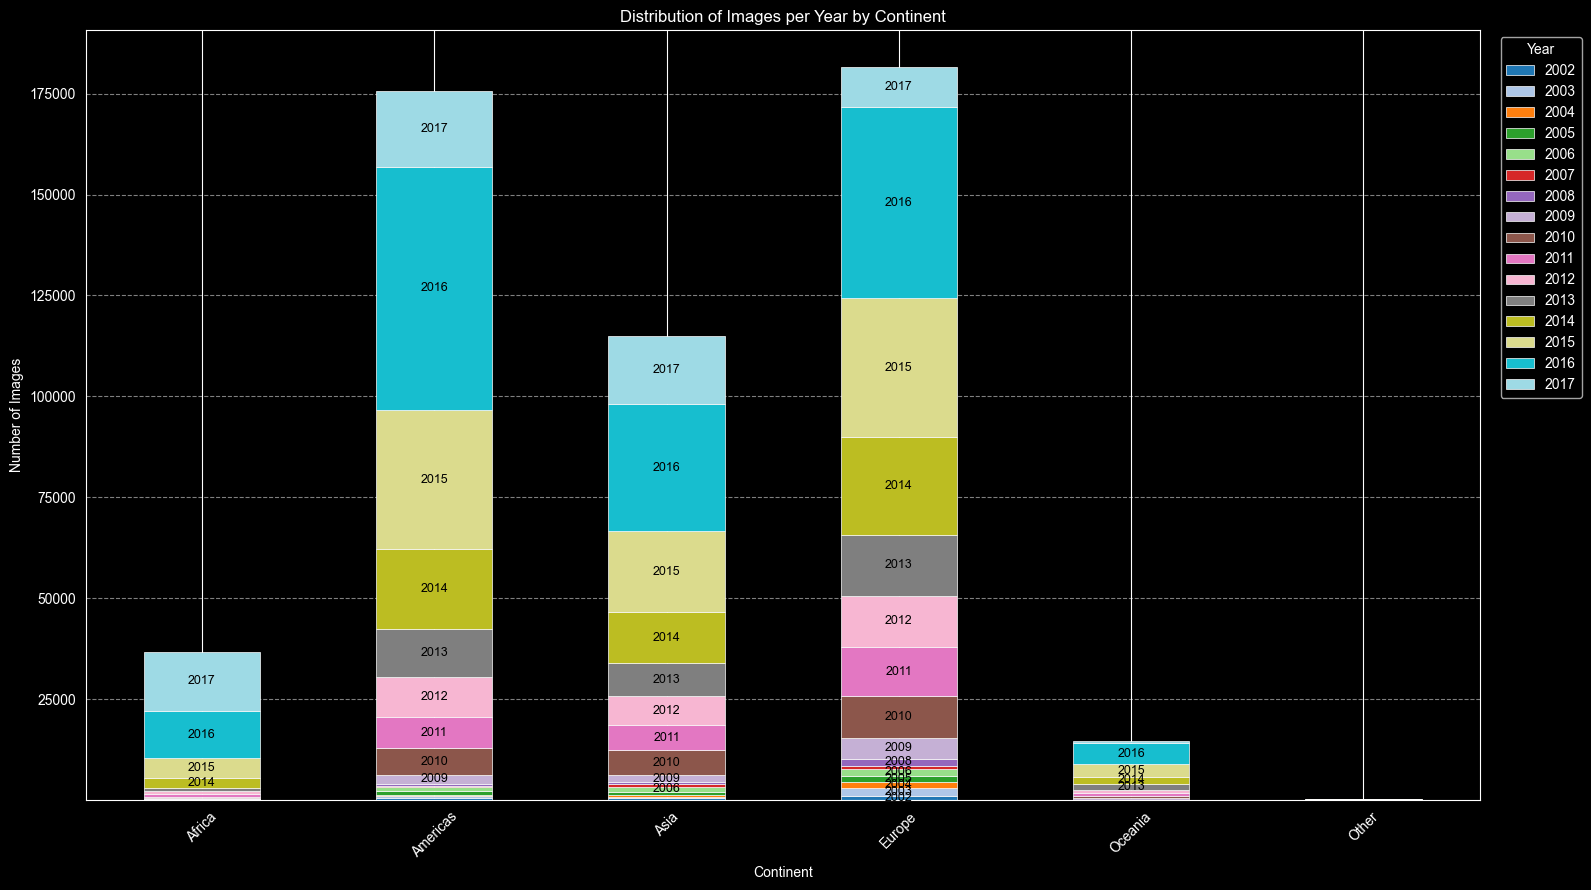

In [25]:
#per ogni continente, vedere la distribuzione delle immagini negli anni (fissato il continente, vedere la distribuzione delle immagini negli anni)


data_pivot = df.groupby(['region_names','year_extracted']).size().unstack(fill_value=0)

# 2. Create the plot and capture the 'ax' (axes) object
fig, ax = plt.subplots(figsize=(16, 9))
data_pivot.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', edgecolor='white', linewidth=0.5)

plt.title('Distribution of Images per Year by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Images')

# 3. Loop through the bar segments and add the year text inside!
# In a stacked bar chart, each container represents one column (one Year)
for container in ax.containers:
    # The label of the container is the actual year (e.g., 2011)
    year = container.get_label()

    # Create a list of labels for this specific year across all continents.
    # We only write the year if the bar segment represents more than 1000 images
    # to keep the chart clean and prevent text overlapping on tiny slivers.
    labels = [year if bar.get_height() > 1000 else "" for bar in container]

    # Add the text to the center of the bar segment
    ax.bar_label(container, labels=labels, label_type='center', color='black', fontsize=9)

# 4. Formatting
plt.legend(title='Year', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [12]:
#fissato anno e continente, devo ordinare le immagini "simulando il passaggio del satellite"

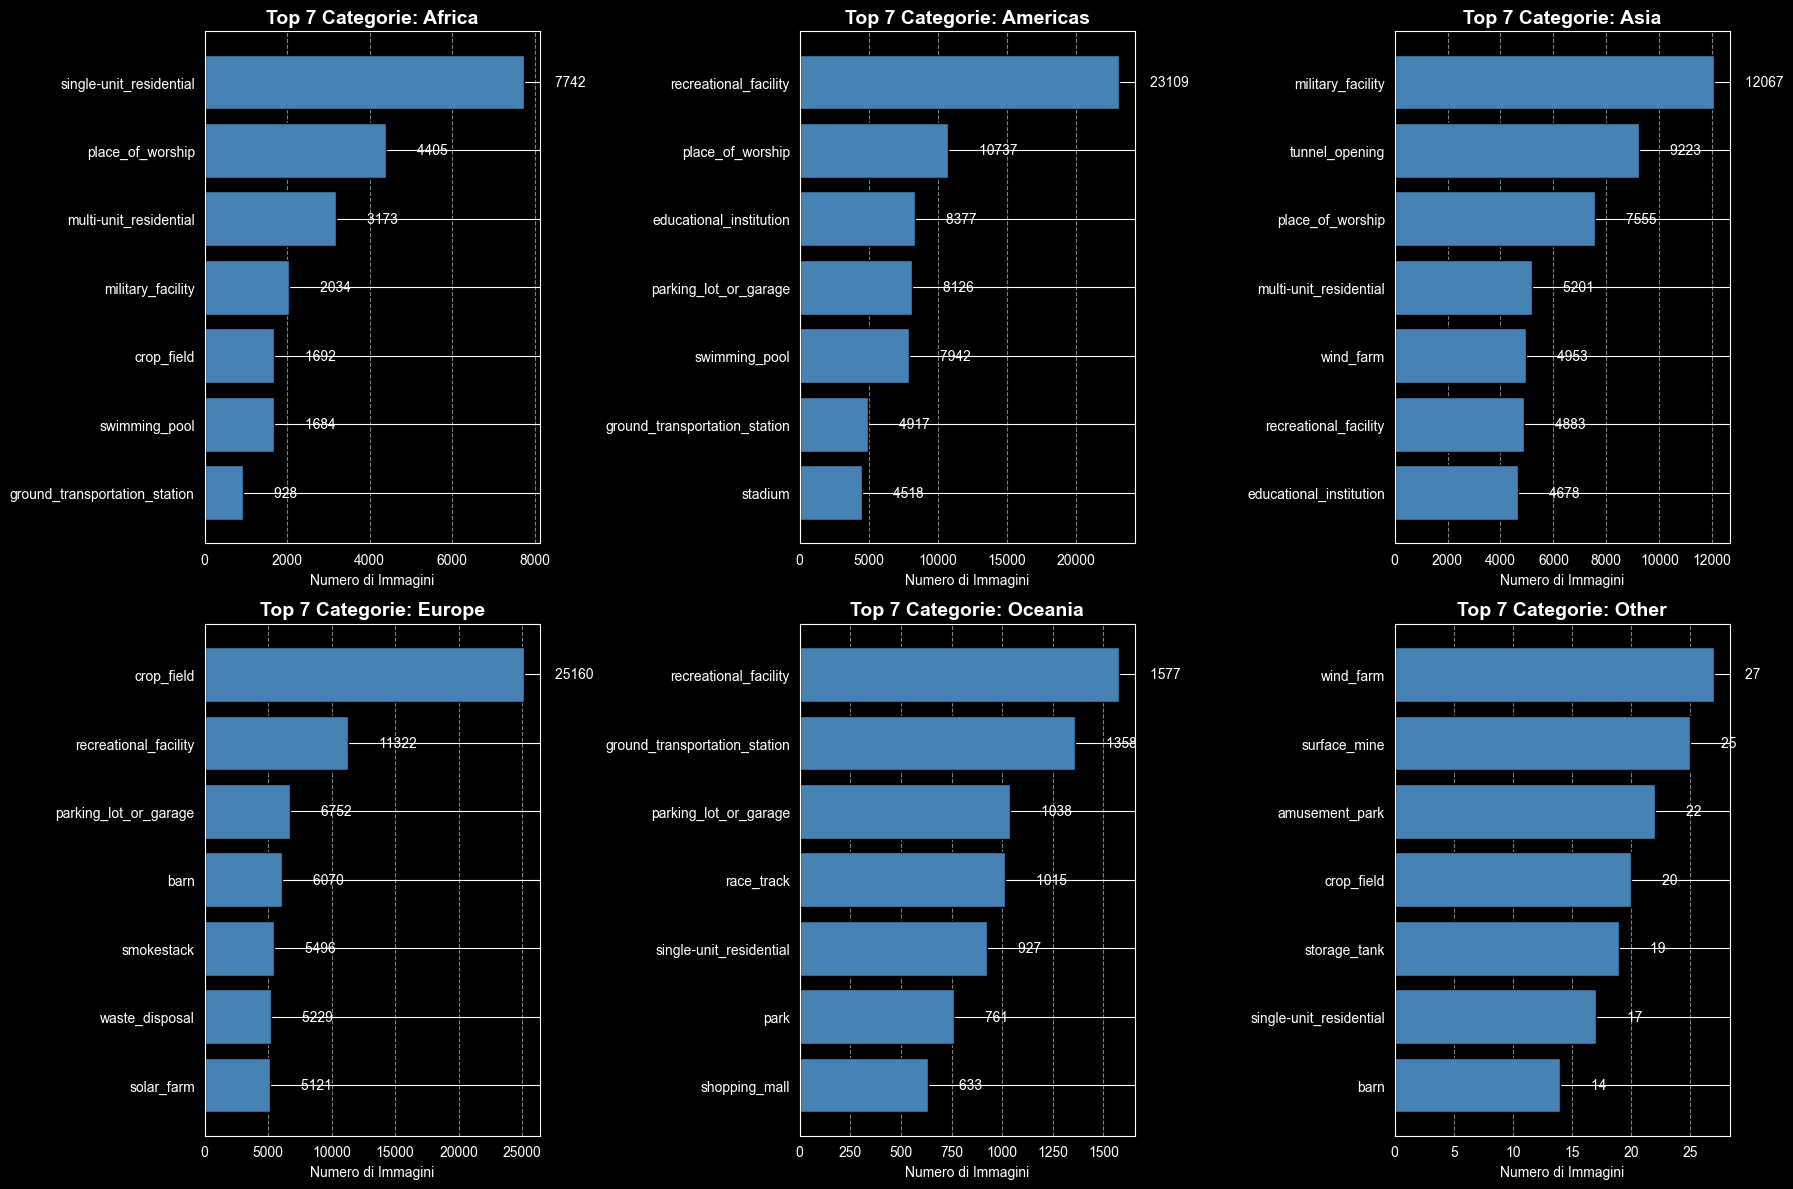

In [36]:
#fissato un continente, vediamo la distribuzione dei label
# 1. Calcoliamo il totale delle immagini per ogni combinazione di Continente e Categoria
counts = df.groupby(['region_names', 'category_name']).size().reset_index(name='count')

top_per_region = (counts.sort_values(['region_names', 'count'], ascending=[True, False])
                  .groupby('region_names')
                  .head(7))

# 3. Prepariamo una griglia per i grafici (assumendo ~6 continenti, facciamo 2 righe e 3 colonne)
continents = top_per_region['region_names'].unique()
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
axes = axes.flatten() # Appiattiamo l'array degli assi per iterarci facilmente

# 4. Disegniamo un grafico per ogni continente
for i, continent in enumerate(continents):
    ax = axes[i]

    # Estraiamo solo i dati di questo continente
    subset = top_per_region[top_per_region['region_names'] == continent]

    # Li riordiniamo al contrario solo per far apparire la barra più lunga in alto nel grafico
    subset = subset.sort_values('count', ascending=True)

    # Creiamo il grafico a barre orizzontali
    ax.barh(subset['category_name'], subset['count'], color='steelblue', edgecolor='black')

    # Aggiungiamo i numeri esatti alla fine di ogni barra per massima chiarezza
    for index, value in enumerate(subset['count']):
        ax.text(value, index, f'        {value}', va='center', fontsize=10)

    # Formattazione del singolo riquadro
    ax.set_title(f"Top 7 Categorie: {continent}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Numero di Immagini")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

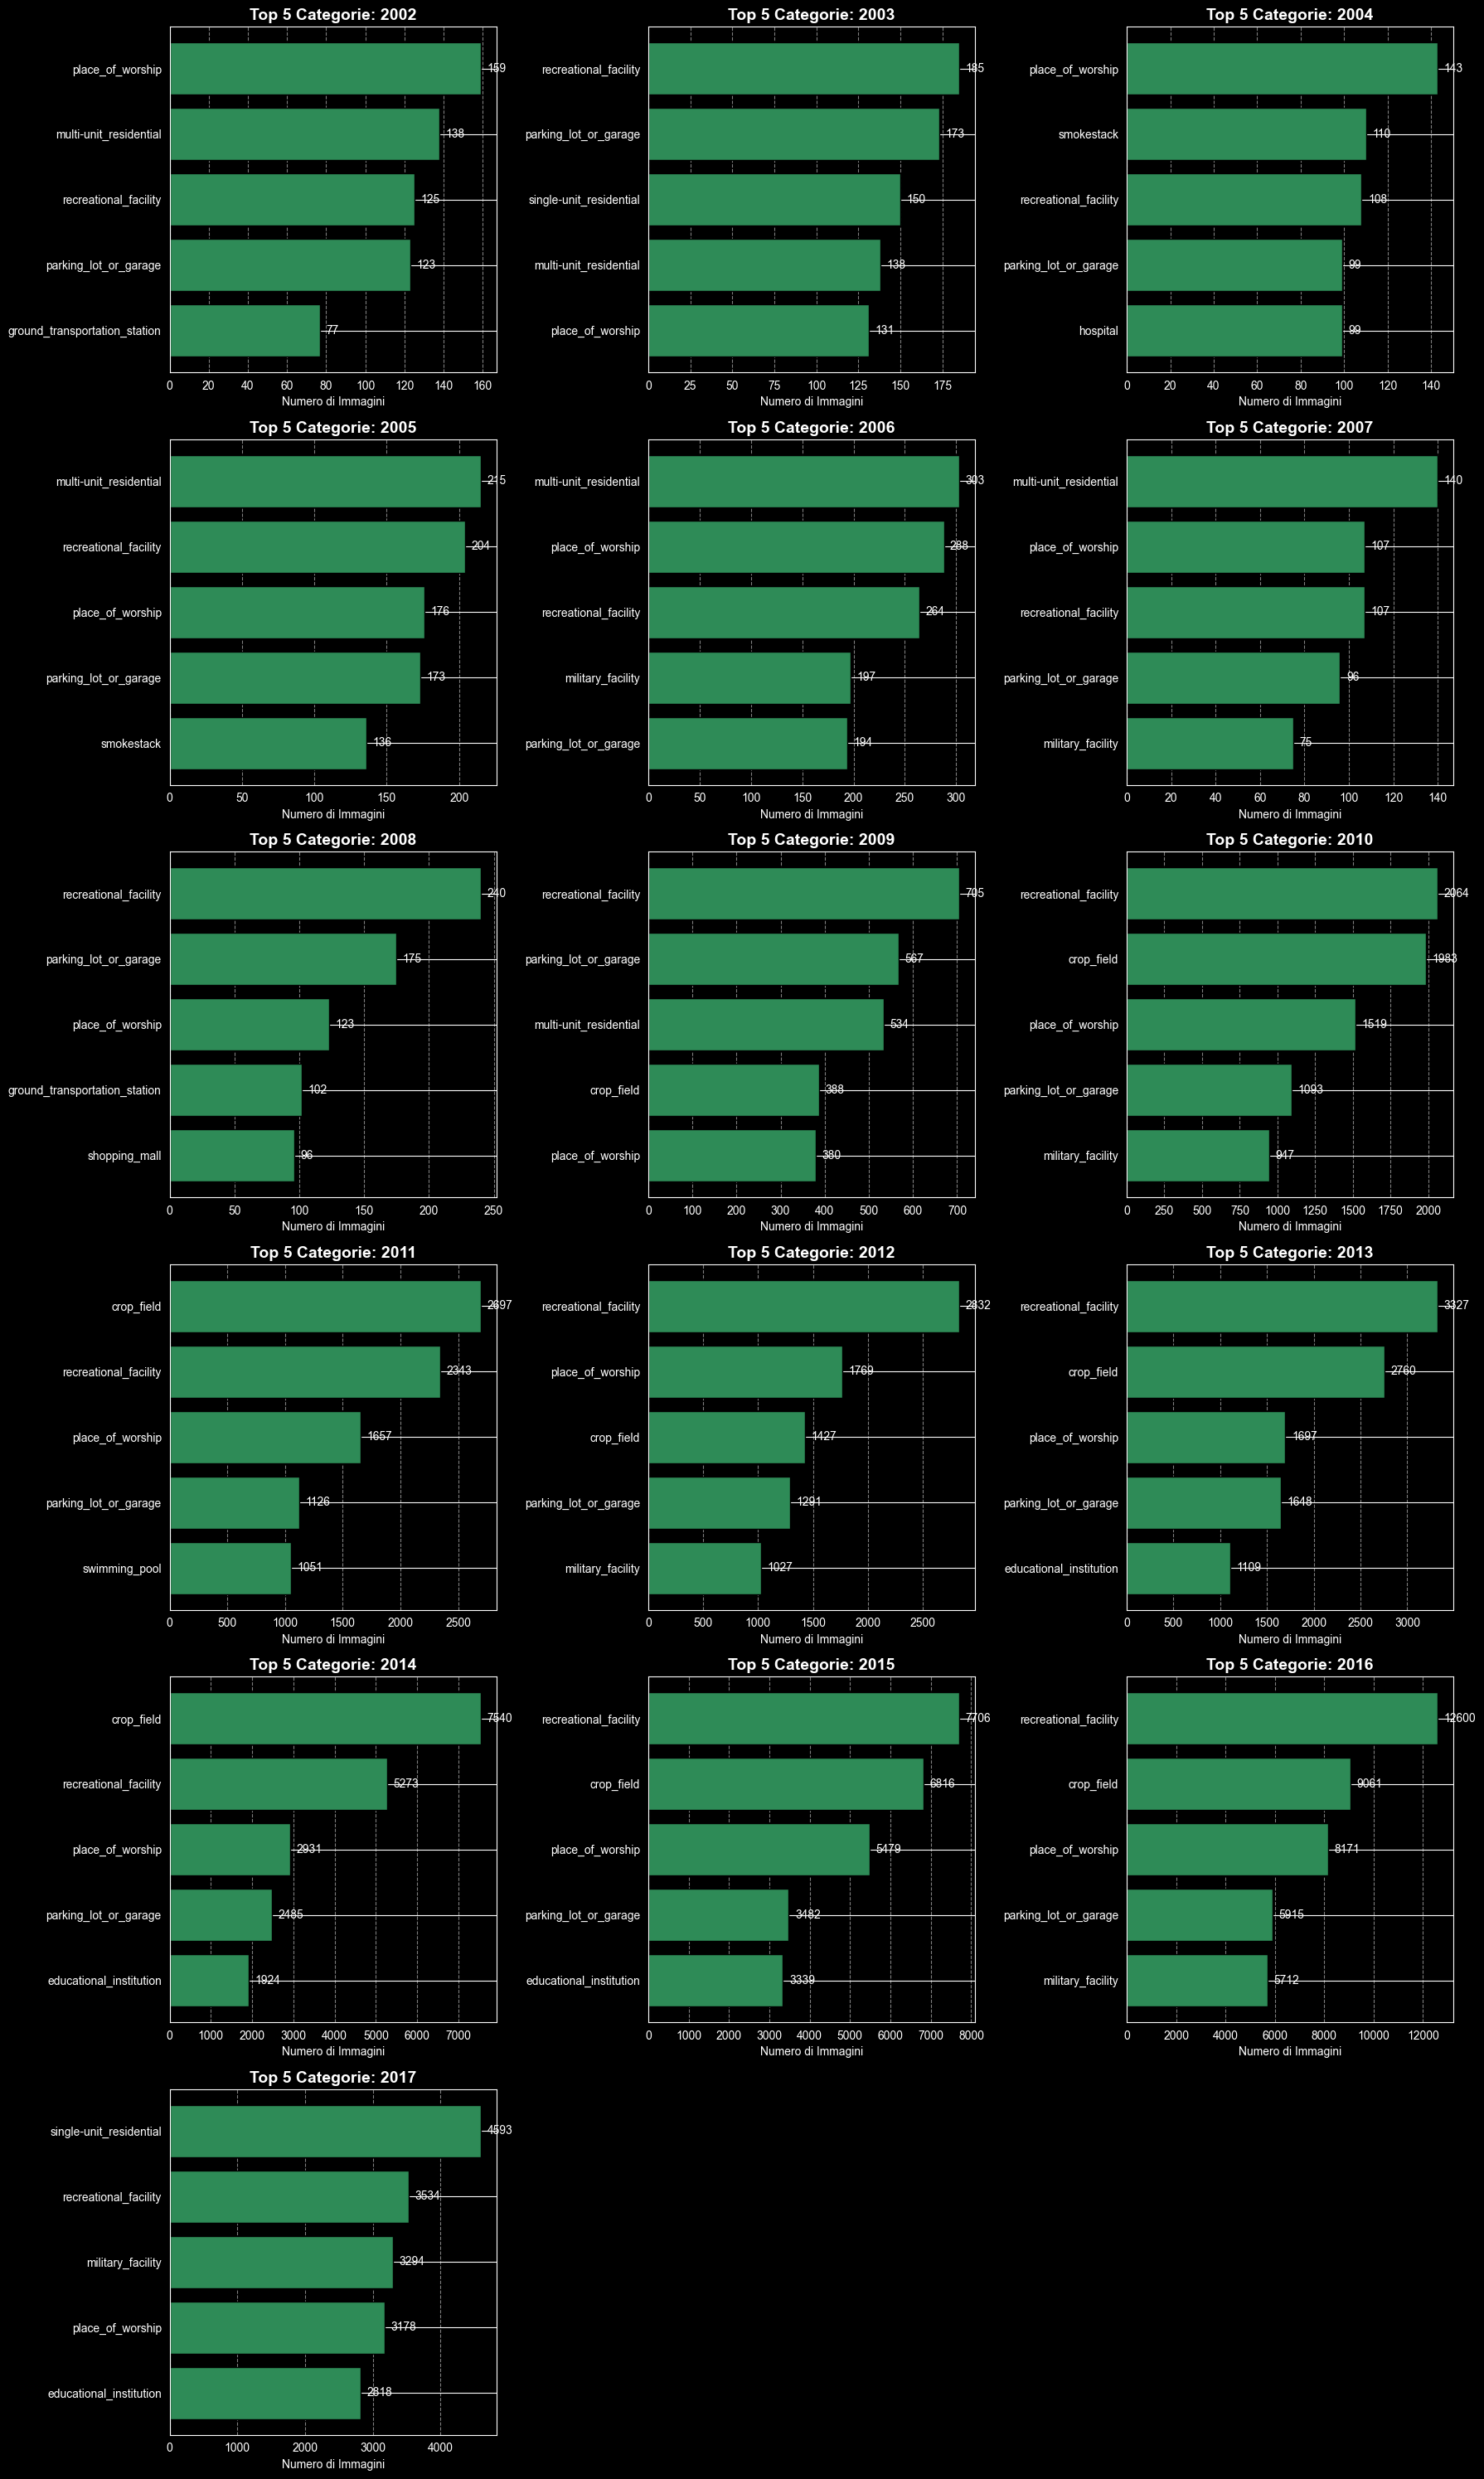

In [41]:
import math

#fissato un anno, vediamo la distribuzione dei label
# 1. Calcoliamo il totale delle immagini per ogni combinazione di Continente e Categoria
counts = df.groupby(['year_extracted','category_name']).size().reset_index(name='count')

top_per_year = (counts.sort_values(['year_extracted', 'count'], ascending=[True, False])
                  .groupby('year_extracted')
                  .head(5))

# 2. Prepariamo la griglia DINAMICA
years = top_per_year['year_extracted'].unique()
num_years = len(years)

# Vogliamo 3 colonne, calcoliamo quante righe servono usando la divisione per eccesso
ncols = 3
nrows = math.ceil(num_years / ncols)

# Rendiamo l'altezza della figura proporzionale al numero di righe
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() # Appiattiamo l'array degli assi per iterarci facilmente

# 3. Disegniamo un grafico per ogni anno
for i, year in enumerate(years):
    ax = axes[i]

    # Estraiamo solo i dati di questo anno
    subset = top_per_year[top_per_year['year_extracted'] == year]

    # Li riordiniamo al contrario per far apparire la barra più lunga in alto
    subset = subset.sort_values('count', ascending=True)

    # Creiamo il grafico a barre orizzontali
    ax.barh(subset['category_name'], subset['count'], color='seagreen', edgecolor='black')

    # Aggiungiamo i numeri esatti alla fine di ogni barra
    # Calcoliamo un piccolo margine dinamico (2% del valore massimo) per staccare il testo dalla barra
    padding = subset['count'].max() * 0.02
    for index, value in enumerate(subset['count']):
        ax.text(value + padding, index, str(value), va='center', fontsize=10)

    # Formattazione del singolo riquadro (assicurandoci che l'anno sia un numero intero)
    ax.set_title(f"Top {5} Categorie: {int(year)}", fontsize=14, fontweight='bold')
    ax.set_xlabel("Numero di Immagini")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Nascondiamo eventuali riquadri vuoti in fondo alla griglia
# (es. se abbiamo 16 anni, la griglia 6x3 ha 18 spazi, i due in più vanno nascosti)
for j in range(num_years, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()